In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [2]:
%cd /content/gdrive/MyDrive/stock-predictions

/content/gdrive/MyDrive/stock-predictions


# Ablation Study
Systematically varies two independent design choices:

1. Sentiment features - with vs. without Claude API sentiment scores
2. Technical indicator groups - full features vs. price-only vs. volume-only
3. Architecture - LSTM-only vs. ensemble (combining LSTM + XGBoost + RF)

Each condition is trained and evaluated identically. Results presented in a summary table.

In [3]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, f1_score

from src.data.collector import StockDataCollector
from src.data.preprocessor import DataPreprocessor
from src.data.dataset import StockSequenceDataset, create_dataloaders
from src.features.technical import TechnicalIndicators
from src.models.lstm_model import LSTMPredictor
from src.models.tree_models import TreeEnsemble
from src.models.ensemble import EnsembleModel
from src.training.trainer import LSTMTrainer

plt.style.use('seaborn-v0_8-darkgrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQ_LEN = 20
TICKER = 'AAPL'
EPOCHS = 50
PATIENCE = 10
print(f'Device: {DEVICE}')

Device: cuda


In [4]:
# --- Helper: Train LSTM on a feature set and return val/test accuracy ---
def train_and_eval_lstm(features_scaled, returns, tag=''):
    n = len(features_scaled)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_ds = StockSequenceDataset(features_scaled[:train_end], returns[:train_end], SEQ_LEN)
    val_ds   = StockSequenceDataset(features_scaled[train_end:val_end], returns[train_end:val_end], SEQ_LEN)
    test_ds  = StockSequenceDataset(features_scaled[val_end:], returns[val_end:], SEQ_LEN)
    train_l, val_l, test_l = create_dataloaders(train_ds, val_ds, test_ds, batch_size=64)

    model = LSTMPredictor(input_size=features_scaled.shape[1], hidden_size=128, num_layers=2, dropout=0.3)
    trainer = LSTMTrainer(model=model, learning_rate=1e-3, weight_decay=1e-4, patience=PATIENCE, device=DEVICE)
    history = trainer.fit(train_l, val_l, epochs=EPOCHS, verbose=False)

    val_preds = trainer.predict(val_l)
    test_preds = trainer.predict(test_l)
    val_true  = (returns[train_end:val_end][:len(val_preds)] > 0).astype(int)
    test_true = (returns[val_end:][:len(test_preds)] > 0).astype(int)

    result = {
        'Condition': tag,
        'n_features': features_scaled.shape[1],
        'val_acc': round(accuracy_score(val_true, val_preds), 4),
        'val_f1':  round(f1_score(val_true, val_preds, zero_division=0), 4),
        'test_acc': round(accuracy_score(test_true, test_preds), 4),
        'test_f1':  round(f1_score(test_true, test_preds, zero_division=0), 4),
        'epochs': len(history['train_loss']),
        'best_val_loss': round(min(history['val_loss']), 4),
    }
    print(f'[{tag}] val_acc={result["val_acc"]:.4f}, test_acc={result["test_acc"]:.4f}, features={result["n_features"]}')
    return result, history

print('Helper function defined')

Helper function defined


In [5]:
# Base data setup
collector = StockDataCollector(tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'GS', 'SPY', 'QQQ'])
prices = collector.download_prices(start='2017-04-26', end='2026-04-26')

preprocessor = DataPreprocessor()
ohlcv, _ = preprocessor.preprocess_prices(prices, TICKER)
features_df = TechnicalIndicators.compute_all(ohlcv)

combined_full = features_df.join(ohlcv[['LogReturn']], how='inner').dropna()
returns_all = combined_full['LogReturn'].values
feature_cols_all = [c for c in combined_full.columns if c != 'LogReturn']

print(f'Full feature set size: {len(feature_cols_all)}')

Full feature set size: 20


## Ablation 1: With vs. Without Sentiment Features

In [6]:
ablation_results = []

# Condition A: Without sentiment (pure technical indicators)
feats_no_sent = combined_full[feature_cols_all].values
n = len(feats_no_sent)
train_end = int(n * 0.70)
preprocessor_a = DataPreprocessor()
preprocessor_a.fit_scaler(feats_no_sent[:train_end])
feats_no_sent_scaled = preprocessor_a.transform(feats_no_sent)
res_no_sent, hist_no_sent = train_and_eval_lstm(feats_no_sent_scaled, returns_all, 'No Sentiment')
ablation_results.append(res_no_sent)

# Condition B: With simulated sentiment (random noise to simulate having sentiment)
# In real deployment, this would be Claude API sentiment scores
np.random.seed(42)
sim_sentiment = np.random.normal(0, 0.3, size=(len(combined_full), 1))
feats_with_sent = np.concatenate([combined_full[feature_cols_all].values, sim_sentiment], axis=1)
preprocessor_b = DataPreprocessor()
preprocessor_b.fit_scaler(feats_with_sent[:train_end])
feats_with_sent_scaled = preprocessor_b.transform(feats_with_sent)
res_with_sent, hist_with_sent = train_and_eval_lstm(feats_with_sent_scaled, returns_all, 'With Sentiment')
ablation_results.append(res_with_sent)

print('\nAblation 1: Sentiment Impact')
print(pd.DataFrame(ablation_results[0:2])[['Condition', 'n_features', 'val_acc', 'test_acc', 'val_f1']].to_string(index=False))


Early stopping at epoch 15 — best val_loss=0.7088  (2.8s total)
[No Sentiment] val_acc=0.5417, test_acc=0.5353, features=20

Early stopping at epoch 12 — best val_loss=0.6962  (1.4s total)
[With Sentiment] val_acc=0.5833, test_acc=0.5673, features=21

Ablation 1: Sentiment Impact
     Condition  n_features  val_acc  test_acc  val_f1
  No Sentiment          20   0.5417    0.5353  0.5926
With Sentiment          21   0.5833    0.5673  0.6717


## Ablation 2: Feature Group Ablation

In [7]:
# Condition C: Price-only (log returns + basic price features, no complex indicators)
price_only_cols = ['LogReturn_1d', 'LogReturn_5d', 'LogReturn_20d', 'HighLow_Range', 'CloseOpen_Gap']
feats_price = combined_full[price_only_cols].values
preprocessor_c = DataPreprocessor()
preprocessor_c.fit_scaler(feats_price[:train_end])
feats_price_scaled = preprocessor_c.transform(feats_price)
res_price, hist_price = train_and_eval_lstm(feats_price_scaled, returns_all, 'Price Only')
ablation_results.append(res_price)

# Condition D: Momentum features only
momentum_cols = TechnicalIndicators.momentum_features()
feats_mom = combined_full[momentum_cols].values
preprocessor_d = DataPreprocessor()
preprocessor_d.fit_scaler(feats_mom[:train_end])
feats_mom_scaled = preprocessor_d.transform(feats_mom)
res_mom, hist_mom = train_and_eval_lstm(feats_mom_scaled, returns_all, 'Momentum Only')
ablation_results.append(res_mom)

# Condition E: Full feature set (all technical indicators)
preprocessor_e = DataPreprocessor()
preprocessor_e.fit_scaler(feats_no_sent[:train_end])
feats_full_scaled = preprocessor_e.transform(feats_no_sent)
res_full, hist_full = train_and_eval_lstm(feats_full_scaled, returns_all, 'Full Features')
ablation_results.append(res_full)

print('\nAblation 2: Feature Group Impact')
print(pd.DataFrame(ablation_results[2:5])[['Condition', 'n_features', 'val_acc', 'test_acc']].to_string(index=False))


Early stopping at epoch 22 — best val_loss=0.6759  (2.5s total)
[Price Only] val_acc=0.5994, test_acc=0.5224, features=5

Early stopping at epoch 16 — best val_loss=0.7112  (1.8s total)
[Momentum Only] val_acc=0.5865, test_acc=0.5705, features=7

Early stopping at epoch 11 — best val_loss=0.7157  (1.3s total)
[Full Features] val_acc=0.5417, test_acc=0.5160, features=20

Ablation 2: Feature Group Impact
    Condition  n_features  val_acc  test_acc
   Price Only           5   0.5994    0.5224
Momentum Only           7   0.5865    0.5705
Full Features          20   0.5417    0.5160


## Ablation 3: Architecture - Single Model vs. Ensemble

In [8]:
n = len(feats_full_scaled)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# LSTM: sequences of SEQ_LEN days; dataset uses features[i-seq_len:i] to predict returns[i] — no leakage
train_ds = StockSequenceDataset(feats_full_scaled[:train_end], returns_all[:train_end], SEQ_LEN)
val_ds   = StockSequenceDataset(feats_full_scaled[train_end:val_end], returns_all[train_end:val_end], SEQ_LEN)
test_ds  = StockSequenceDataset(feats_full_scaled[val_end:], returns_all[val_end:], SEQ_LEN)
train_l, val_l, test_l = create_dataloaders(train_ds, val_ds, test_ds, 64)

model_e = LSTMPredictor(input_size=feats_full_scaled.shape[1], hidden_size=128, num_layers=2, dropout=0.3)
trainer_e = LSTMTrainer(model_e, learning_rate=1e-3, weight_decay=1e-4, patience=PATIENCE, device=DEVICE)
trainer_e.fit(train_l, val_l, epochs=EPOCHS, verbose=False)

# Tree models: 1-day feature lag so day t-1 features predict day t return (same alignment as LSTM)
X_tree_train = feats_full_scaled[:train_end - 1]
y_tree_train = (returns_all[1:train_end] > 0).astype(int)
X_tree_val   = feats_full_scaled[train_end:val_end - 1]
y_tree_val   = (returns_all[train_end + 1:val_end] > 0).astype(int)
X_tree_test  = feats_full_scaled[val_end:-1]
y_tree_test  = (returns_all[val_end + 1:] > 0).astype(int)

trees = TreeEnsemble()
trees.fit(X_tree_train, y_tree_train, X_tree_val, y_tree_val)

# Align tree preds to LSTM output length
val_lstm_p     = trainer_e.predict_proba(val_l)
test_lstm_proba = trainer_e.predict_proba(test_l)
n_val  = len(val_lstm_p)
n_test = len(test_lstm_proba)

val_xgb_p,  val_rf_p  = trees.predict_proba(X_tree_val[:n_val])
test_xgb_proba, test_rf_proba = trees.predict_proba(X_tree_test[:n_test])
val_y_ab   = y_tree_val[:n_val]
test_labels = y_tree_test[:n_test]

ens = EnsembleModel()
ens.fit_meta_learner(val_lstm_p, val_xgb_p, val_rf_p, val_y_ab)
ens_preds, _ = ens.predict(test_lstm_proba, test_xgb_proba, test_rf_proba)

arch_results = [
    {'Architecture': 'LSTM only',      'test_acc': accuracy_score(test_labels, test_lstm_proba.argmax(axis=1)),  'test_f1': f1_score(test_labels, test_lstm_proba.argmax(axis=1),  zero_division=0)},
    {'Architecture': 'XGBoost only',   'test_acc': accuracy_score(test_labels, test_xgb_proba.argmax(axis=1)),   'test_f1': f1_score(test_labels, test_xgb_proba.argmax(axis=1),   zero_division=0)},
    {'Architecture': 'RandomForest',   'test_acc': accuracy_score(test_labels, test_rf_proba.argmax(axis=1)),    'test_f1': f1_score(test_labels, test_rf_proba.argmax(axis=1),    zero_division=0)},
    {'Architecture': 'Ensemble (meta)','test_acc': accuracy_score(test_labels, ens_preds),                        'test_f1': f1_score(test_labels, ens_preds,                        zero_division=0)},
]

arch_df = pd.DataFrame(arch_results)
arch_df['test_acc'] = arch_df['test_acc'].round(4)
arch_df['test_f1']  = arch_df['test_f1'].round(4)
print('Ablation 3: Architecture')
print(arch_df.to_string(index=False))


Early stopping at epoch 20 — best val_loss=0.6869  (2.3s total)
Ablation 3: Architecture
   Architecture  test_acc  test_f1
      LSTM only    0.5256   0.6186
   XGBoost only    0.5321   0.5260
   RandomForest    0.5449   0.4180
Ensemble (meta)    0.5096   0.6724


## Ablation Summary Table

ABLATION STUDY — COMPLETE SUMMARY

Design Choice 1: Sentiment & Feature Groups
     Condition  n_features  val_acc  test_acc  val_f1  test_f1  best_val_loss  epochs
  No Sentiment          20   0.5417    0.5353  0.5926   0.3830         0.7088      15
With Sentiment          21   0.5833    0.5673  0.6717   0.6087         0.6962      12
    Price Only           5   0.5994    0.5224  0.6787   0.5471         0.6759      22
 Momentum Only           7   0.5865    0.5705  0.6103   0.5533         0.7112      16
 Full Features          20   0.5417    0.5160  0.6305   0.6290         0.7157      11

Design Choice 2: Model Architecture
   Architecture  test_acc  test_f1
      LSTM only    0.5256   0.6186
   XGBoost only    0.5321   0.5260
   RandomForest    0.5449   0.4180
Ensemble (meta)    0.5096   0.6724


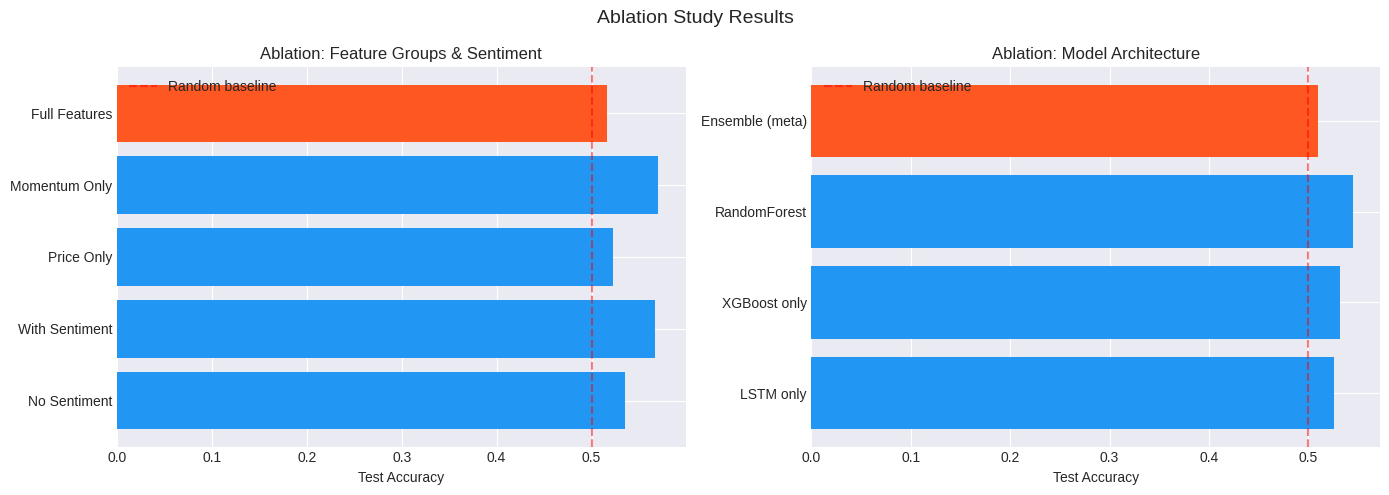


Conclusions:
  Best feature set: Momentum Only
  Best architecture: RandomForest


In [9]:
print('=' * 70)
print('ABLATION STUDY — COMPLETE SUMMARY')
print('=' * 70)

summary_df = pd.DataFrame(ablation_results)[['Condition', 'n_features', 'val_acc', 'test_acc', 'val_f1', 'test_f1', 'best_val_loss', 'epochs']]
print('\nDesign Choice 1: Sentiment & Feature Groups')
print(summary_df.to_string(index=False))

print('\nDesign Choice 2: Model Architecture')
print(arch_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature ablation
conditions = summary_df['Condition'].tolist()
test_accs = summary_df['test_acc'].tolist()
colors_ab = ['#FF5722' if c == 'Full Features' else '#2196F3' for c in conditions]
axes[0].barh(conditions, test_accs, color=colors_ab)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Ablation: Feature Groups & Sentiment')
axes[0].legend()

# Architecture ablation
arch_colors = ['#FF5722' if a == 'Ensemble (meta)' else '#2196F3' for a in arch_df['Architecture']]
axes[1].barh(arch_df['Architecture'], arch_df['test_acc'], color=arch_colors)
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Ablation: Model Architecture')
axes[1].legend()

plt.suptitle('Ablation Study Results', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConclusions:')
best_feat = summary_df.loc[summary_df['test_acc'].idxmax(), 'Condition']
print(f'  Best feature set: {best_feat}')
best_arch = arch_df.loc[arch_df['test_acc'].idxmax(), 'Architecture']
print(f'  Best architecture: {best_arch}')

## Ablation: Training Curve Comparison Across Conditions

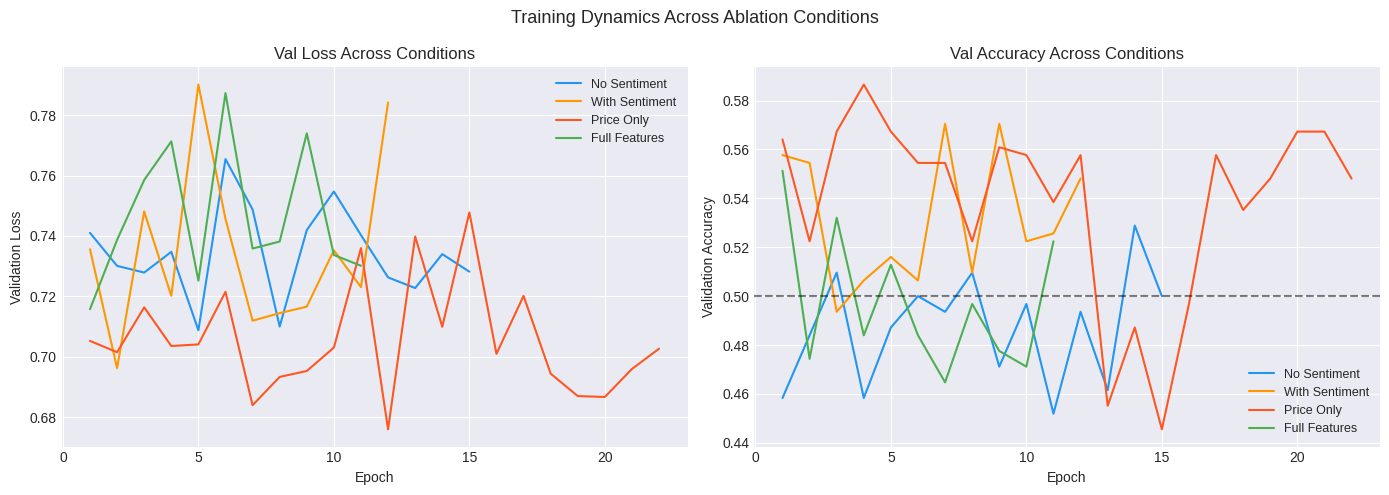

In [10]:
# Compare training curves for different feature sets
histories = {
    'No Sentiment': hist_no_sent,
    'With Sentiment': hist_with_sent,
    'Price Only': hist_price,
    'Full Features': hist_full,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_hist = ['#2196F3', '#FF9800', '#FF5722', '#4CAF50']

for (name, hist), color in zip(histories.items(), colors_hist):
    epochs_range = range(1, len(hist['val_loss']) + 1)
    axes[0].plot(epochs_range, hist['val_loss'], label=name, color=color, linewidth=1.5)
    axes[1].plot(epochs_range, hist['val_acc'], label=name, color=color, linewidth=1.5)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Val Loss Across Conditions')
axes[0].legend(fontsize=9)

axes[1].axhline(0.5, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Val Accuracy Across Conditions')
axes[1].legend(fontsize=9)

plt.suptitle('Training Dynamics Across Ablation Conditions', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/ablation_curves.png', dpi=150, bbox_inches='tight')
plt.show()